# **LIMPIEZA DE TEXTO**

In [ ]:
#pip install python-dotenv
#pip install openai
#pip install spacy unidecode
#python -m spacy download es_core_news_sm
#pip install fonttools
#pip install -q textblob
#pip install spacy
#python -m spacy download es_core_news_sm
#pip install wordcloud
#pip install ufal.udpipe
#pip install pyspellchecker
#wget https://lindat.mff.cuni.cz/repository/xmlui/bitstream/handle/11234/1-3131/spanish-gsd-ud-2.5-191206.udpipe
#python -m spacy download es_core_news_sm
#python -m spacy download es_core_news_md
#pip install igraph

In [ ]:
from textblob import TextBlob
import spacy
nlp = spacy.load("es_core_news_sm")
from dotenv import load_dotenv
import openai
import os
import re
from nltk.corpus import stopwords
from nltk.corpus import words
from nltk.tokenize import word_tokenize
from nltk.util import ngrams
import networkx as nx
import matplotlib.pyplot as plt
import nltk
import numpy as np
nltk.download('stopwords')
nltk.download('words')
import pandas as pd
import unicodedata
nltk.download('punkt')
import random
import seaborn as sns
import statsmodels.api as sm
from scipy.stats import shapiro, bartlett, pearsonr
import community
from wordcloud import WordCloud
from nltk.probability import FreqDist
import subprocess
import pickle
import igraph as ig
import unidecode
from itertools import combinations
from collections import Counter
from unidecode import unidecode
import math
nltk.download('punkt_tab')
import spacy
from tqdm import tqdm
from nltk import FreqDist
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import unicodedata

In [5]:
#FUNCIONES DE LIMPIEZA DE TEXTO
def limpiar_texto(texto):
    # Convertir texto a minúsculas
    texto = texto.lower()

    # Quitar caracteres especiales y números
    texto = re.sub(r'[^a-zA-ZñÑáéíóúÁÉÍÓÚó\s]', '', texto)
    texto = ''.join((c for c in unicodedata.normalize('NFD', texto) if unicodedata.category(c) != 'Mn'))

    return texto

def quitar_stopwords(texto):
    # Tokenizar el texto
    tokens = word_tokenize(texto)

    # Quitar stopwords
    texto_limpio = [word for word in tokens if word not in stop_words]

    return ' '.join(texto_limpio)


def generar_skipgramas(texto, n=2, k=2):
    tokens = word_tokenize(texto)
    skipgramas = []
    for i in range(len(tokens)):
        for j in range(i + 1, min(i + k + 2, len(tokens))):
            skipgramas.append((tokens[i], tokens[j]))

    return skipgramas


def eliminar_palabras_cortas(texto):
    excepciones = {"up", "fé", "fe"}
    palabras = texto.split()
    palabras_filtradas = [
        palabra for palabra in palabras
        if len(palabra) > 2 or palabra.lower() in excepciones
    ]
    texto_filtrado = ' '.join(palabras_filtradas)
    return texto_filtrado

In [ ]:
carpeta = 'C:/Users/Desktop/caso_09'
textos_20241108 = []
textos_0240726 = []
textos_20241114 = []
textos_luis20240621 = []
textos_luis20240729 = []
textos_20240503 = []
textos_fernando = []
textos_valledupar = []

for archivo in os.listdir(carpeta):
    if archivo.endswith('.txt'):
        ruta_archivo = os.path.join(carpeta, archivo)
        with open(ruta_archivo, 'r', encoding='utf-8') as f:
            contenido = f.read()

        # normalizar: minúsculas, quitar tildes y signos
        archivo_norm = unidecode(archivo.lower())
        archivo_norm = archivo_norm.replace(',', '').replace('-', ' ').replace('_', ' ')

        if '20241108' in archivo_norm:
            textos_20241108 .append((archivo, contenido))

        elif '0240726' in archivo_norm:
            textos_0240726.append((archivo, contenido))

        elif '20241114' in archivo_norm:
            textos_20241114.append((archivo, contenido))

        elif '20240621' in archivo_norm:
            textos_luis20240621.append((archivo, contenido))

        elif '20240729' in archivo_norm:
            textos_luis20240729.append((archivo, contenido))

        elif '20240503' in archivo_norm:
            textos_20240503.append((archivo, contenido))

        elif 'fernando urrego' in archivo_norm:
            textos_fernando.append((archivo, contenido))

        else:
            textos_valledupar.append((archivo, contenido))

texto_20241108 = ' '.join([contenido for _, contenido in textos_20241108])
texto_0240726 = ' '.join([contenido for _, contenido in textos_0240726])
texto_20241114 = ' '.join([contenido for _, contenido in textos_20241114])
texto_luis20240621 = ' '.join([contenido for _, contenido in  textos_luis20240621])
texto_luis20240729 =  ' '.join([contenido for _, contenido in  textos_luis20240729])
texto_20240503 = ' '.join([contenido for _, contenido in  textos_20240503])
texto_fernando = ' '.join([contenido for _, contenido in  textos_fernando])
texto_valledupar = ' '.join([contenido for _, contenido in  textos_valledupar ])

print(f"Archivos de 1: {len(texto_20241108)}")
print(f"Archivos de 2: {len(texto_0240726)}")
print(f"Archivos de 3: {len(texto_20241114)}")
print(f"Archivos de 4: {len(texto_luis20240621)}")
print(f"Archivos de 5: {len(texto_luis20240729)}")
print(f"Archivos de 6: {len(texto_20240503)}")
print(f"Archivos de 7: {len(texto_fernando)}")
print(f"Archivos de 8: {len(texto_valledupar)}")


Archivos de 1: 80644
Archivos de 2: 225236
Archivos de 3: 182445
Archivos de 4: 10789
Archivos de 5: 100219
Archivos de 6: 187751
Archivos de 7: 230960
Archivos de 8: 209455


In [ ]:
#Primera lematización con términos reconocidos (ej adverbios)
lematizaciones = {}
with open('C:/Users/Desktop/Casos_JEP/lematizacion.txt', 'r', encoding='utf-8') as f:
    for linea in f:
        if ':' in linea:
            palabra, lema = linea.strip().split(':')
            lematizaciones[palabra.strip()] = lema.strip()

def aplicar_lematizacion(texto, lematizaciones):
    if isinstance(texto, tuple):
        texto = ' '.join(str(x) for x in texto)
    elif isinstance(texto, list):
        texto = ' '.join(
            ' '.join(str(x) for x in t) if isinstance(t, tuple) else str(t)
            for t in texto
        )

    palabras = texto.split()

    palabras_lematizadas = [
        lematizaciones.get(p.lower(), p.lower())
        for p in palabras
    ]

    return ' '.join(palabras_lematizadas)
textos = {
    'Toma de testimonio 20241108': textos_20241108 ,
    'Toma versión voluntaria 20240726': texto_0240726,
    'Toma versiones voluntarias 20241114': texto_20241114,
    'Toma de testimonio Luis Restrepo 20240621': texto_luis20240621,
    'Toma de testimonio Luis Restrepo 20240729': texto_luis20240729,
    'Toma de testimonios 20240503' : texto_20240503,
    'Versión de Luis Fernando Urrego' : texto_fernando,
    'Versión voluntaria Valledupar' : texto_valledupar
}

textos_lematizados = {}

for nombre, texto in textos.items():
    textos_lematizados[nombre] = aplicar_lematizacion(texto, lematizaciones)

textos_20241108_lem = textos_lematizados['Toma de testimonio 20241108']
texto_0240726_lem = textos_lematizados['Toma versión voluntaria 20240726']
texto_20241114_lem = textos_lematizados['Toma versiones voluntarias 20241114']
texto_luis20240621_lem = textos_lematizados['Toma de testimonio Luis Restrepo 20240621']
texto_luis20240729_lem = textos_lematizados['Toma de testimonio Luis Restrepo 20240729']
texto_20240503_lem = textos_lematizados['Toma de testimonios 20240503']
texto_fernando_lem = textos_lematizados['Versión de Luis Fernando Urrego']
texto_valledupar_lem = textos_lematizados['Versión voluntaria Valledupar']


#Eliminar palabras cortas:
textos_20241108_lem = eliminar_palabras_cortas(textos_20241108_lem )
texto_0240726_lem = eliminar_palabras_cortas(texto_0240726_lem)
texto_20241114_lem = eliminar_palabras_cortas(texto_20241114_lem)
texto_luis2024062_lem = eliminar_palabras_cortas(texto_luis20240621_lem)
texto_20240503_lem = eliminar_palabras_cortas(texto_luis20240729_lem)
texto_20240503_lem = eliminar_palabras_cortas(texto_20240503_lem)
texto_fernando_lem = eliminar_palabras_cortas(texto_fernando_lem)
texto_valledupar_lem = eliminar_palabras_cortas(texto_valledupar_lem)


# tokenizar
textos = {
    'Toma de testimonio 20241108': textos_20241108_lem ,
    'Toma versión voluntaria 20240726': texto_0240726_lem,
    'Toma versiones voluntarias 20241114': texto_20241114_lem,
    'Toma de testimonio Luis Restrepo 20240621': texto_luis20240621_lem,
    'Toma de testimonio Luis Restrepo 20240729': texto_luis20240729_lem,
    'Toma de testimonios 20240503' : texto_20240503_lem,
    'Versión de Luis Fernando Urrego' : texto_fernando_lem,
    'Versión voluntaria Valledupar' : texto_valledupar_lem}

tokens_dict = {}
for nombre, texto in textos.items():
    tokens = nltk.word_tokenize(texto, language="spanish")
    tokens_dict[nombre] = tokens

# **LEMATIZACIÓN Y CORRECCIÓN PREVIA**

In [ ]:
# Lematizacion con Spacy
excepciones = {"voluntaria", "soldado"}
nlp = spacy.load("es_core_news_md", disable=["parser", "ner"])

def lematizar_en_bloques(tokens, bloque_size=10000):
    lemas = []
    for i in tqdm(range(0, len(tokens), bloque_size)):
        bloque = tokens[i:i+bloque_size]
        docs = nlp.pipe(bloque, disable=["parser", "ner"])
        for tok_original, doc in zip(bloque, docs):
            token_spacy = doc[0]
            if tok_original.lower() in excepciones:
                lemas.append(tok_original.lower())
            else:
                lemas.append(token_spacy.lemma_)
    return lemas

lemas_dict = {}
for nombre, tokens in tokens_dict.items():
    print(f"\n Texto: {nombre} ({len(tokens)} tokens)")
    lemas_dict[nombre] = lematizar_en_bloques(tokens, bloque_size=10000)

In [ ]:
# Reconstruir cada texto:
textos_lemas = {
    nombre: " ".join(lemas_dict[nombre])
    for nombre in ['Toma de testimonio 20241108','Toma versión voluntaria 20240726','Toma versiones voluntarias 20241114','Toma de testimonio Luis Restrepo 20240621',
    'Toma de testimonio Luis Restrepo 20240729','Toma de testimonios 20240503', 'Versión de Luis Fernando Urrego','Versión voluntaria Valledupar']}

#emplear lematizacion anterior:
lematizaciones2 = {}
with open('C:/Users/Desktop/Casos_JEP/salida_08.txt', 'r', encoding='utf-8') as f:
    for linea in f:
        if ':' in linea:
            palabra, lema = linea.strip().split(':')
            lematizaciones2[palabra.strip()] = lema.strip()
textos_finales_dicc = {}

for nombre, texto in textos_lemas.items():
    palabras = texto.split()

    texto_lemas_dicc = []
    for palabra in palabras:
        if palabra in lematizaciones2:
            if lematizaciones2[palabra] != "NA":
                texto_lemas_dicc.append(lematizaciones2[palabra])
            # si es "NA", no se agrega nada (se elimina)
        else:
            texto_lemas_dicc.append(palabra)  # si no está en el diccionario, se deja igual

    texto_final = " ".join(texto_lemas_dicc)
    textos_finales_dicc[nombre] = texto_final

In [ ]:
def eliminar_acentos(palabra):
    return ''.join((c for c in unicodedata.normalize('NFD', palabra) if unicodedata.category(c) != 'Mn'))

def normalizar(texto):
    texto = texto.lower()
    texto = unicodedata.normalize("NFD", texto)
    texto = texto.encode("ascii", "ignore").decode("utf-8")
    return texto

# ---------------------------- Stopwords ---------------------------------
stop_words = set(stopwords.words('spanish'))

archivo_stopwords = 'C:/Users/Desktop/Casos_JEP/stop_words_espanol.txt'
with open(archivo_stopwords, 'r', encoding='utf-8') as f:
    for linea in f:
        word = linea.strip()
        stop_words.add(word)
        for palabra in linea.split():
            stop_words.add(eliminar_acentos(palabra.lower()))

# ---------------   -Diccionarios de términos y lemas adicionales ---------------
ruta_palabras = "C:/Users/Desktop/Casos_JEP/palabras_no_validas.txt"
with open(ruta_palabras, "r", encoding="utf-8") as f:
    palabras_no_validas = [line.strip() for line in f if line.strip()]

ruta_lemas = "C:/Users/Desktop/Casos_JEP/lemas_lemas.txt"
lemas_set = set()
lematizaciones_final = {}
with open(ruta_lemas, "r", encoding="utf-8") as f:
    for linea in f:
        if ":" in linea:
            palabra, lema = linea.strip().split(":", 1)
            lemas_set.add(palabra.strip())
            lematizaciones_final[normalizar(palabra.strip())] = normalizar(lema.strip())

filtradas = [p for p in palabras_no_validas if p not in lemas_set]

# ------------------------- Limpiar texto -----------------------------------------
textos_finales_limpios = {}
for nombre, texto_final in textos_finales_dicc.items():
    textos_finales_limpios[nombre] = limpiar_texto(texto_final)

# -------------------------- Lematizar ---------------------------------------------
textos_lema_dicc = {}
for nombre, texto_final_limpio in textos_finales_limpios.items():
    palabras = texto_final_limpio.split()
    palabras_lematizadas = [lematizaciones_final.get(palabra, palabra) for palabra in palabras]
    textos_lema_dicc[nombre] = " ".join(palabras_lematizadas)

textos_filtrados = {}
for nombre, texto_lema in textos_lema_dicc.items():
    palabras = texto_lema.split()
    textos_filtrados[nombre] = " ".join([p for p in palabras if p not in filtradas])

# ------------------------ Generar skipgramas ----------------------------------------
textos_skipgramas = {}
for nombre, texto_filtrado in textos_lema_dicc.items():
    texto_sin_stopwords = quitar_stopwords(texto_filtrado)
    tokens = word_tokenize(texto_sin_stopwords)
    frec = Counter(tokens)
    tokens_filtrados = [t for t in tokens if frec[t] > 1]
    texto_dep = " ".join(tokens_filtrados)
    skipgramas = generar_skipgramas(texto_dep, 2, 2)
    textos_skipgramas[nombre] = {
        "texto_sin_stopwords": texto_dep,
        "skipgramas": skipgramas}

# **GENERAR SKIPGRAMAS**

In [11]:
##eliminar bucles en skipgramas
textos_skipgramas_filtrados = {}

for nombre, datos in textos_skipgramas.items():
    skipgramas = datos["skipgramas"]
#Filtrar skipgramas:
    # Eliminar bucles (a, a)
    skipgramas_sin_bucles = [b for b in skipgramas if b[0] != b[1]]
    conteo = Counter(skipgramas_sin_bucles)
    # Conservar solo los skipgramas con frecuencia > 1
    skipgramas_filtrados = [b for b, f in conteo.items() if f > 1]
    textos_skipgramas_filtrados[nombre] = {
        "texto_sin_stopwords": datos["texto_sin_stopwords"],
        "skipgramas_filtrados": skipgramas_filtrados,
        "frecuencias": conteo}

#calcular frecuencias
tablas_frecuencias = {}
for nombre, datos in textos_skipgramas_filtrados.items():
    conteo = datos["frecuencias"]
    conteo_str = {' '.join(k): v for k, v in conteo.items() if v > 1}
    df_top = pd.DataFrame(Counter(conteo_str).most_common(10), columns=["Skipgrama", "Frecuencia"])
    tablas_frecuencias[nombre] = df_top

    print(f"\nTop 10 skipgramas en '{nombre}':")
    display(df_top)


Top 10 skipgramas en 'Toma de testimonio 20241108':


,Skipgrama,Frecuencia
0,pedro fernandez,60
1,vicente villafane,22
2,fernandez ocampo,15
3,fernandez pedro,14
4,secuestrar matar,9
5,preguntar joel,9
6,joel preguntar,9
7,derecho internacional,8
8,fiscalia informacion,8
9,luis fernando,7



Top 10 skipgramas en 'Toma versión voluntaria 20240726':


,Skipgrama,Frecuencia
0,teniente fernandez,70
1,hermano villafane,59
2,coronel duque,53
3,batallon popa,41
4,unidad tactico,41
5,comandante batallon,33
6,oficial servicio,31
7,pedro fernandez,30
8,vicente villafane,28
9,oficina inteligencia,23



Top 10 skipgramas en 'Toma versiones voluntarias 20241114':


...

,Skipgrama,Frecuencia
0,haciendar betania,22
1,luis alberto,19
2,finca betania,15
3,grupo paramilitar,14
4,betania predio,13
5,contrato comodato,12
6,ejercito nacional,11
7,finca ejercito,11
8,apoderado victima,10
9,restrepo preguntar,10



Top 10 skipgramas en 'Versión de Luis Fernando Urrego':


,Skipgrama,Frecuencia
0,alfonso macia,70
1,brigada movil,61
2,batallon popa,55
3,jose matar,29
4,haciendar betania,28
5,coronel duque,26
6,hoja vida,25
7,carro john,24
8,fuerza publico,19
9,macia alfonso,18



Top 10 skipgramas en 'Versión voluntaria Valledupar':


,Skipgrama,Frecuencia
0,teniente fernandez,44
1,batallon popa,38
2,brigada movil,36
3,coronel duque,34
4,hermano villafane,30
5,comandante brigada,29
6,vicente villafane,27
7,comandante batallon,27
8,convertir vida,25
9,pedro fernandez,24


# **ANÁLISIS DESCRIPTIVO**

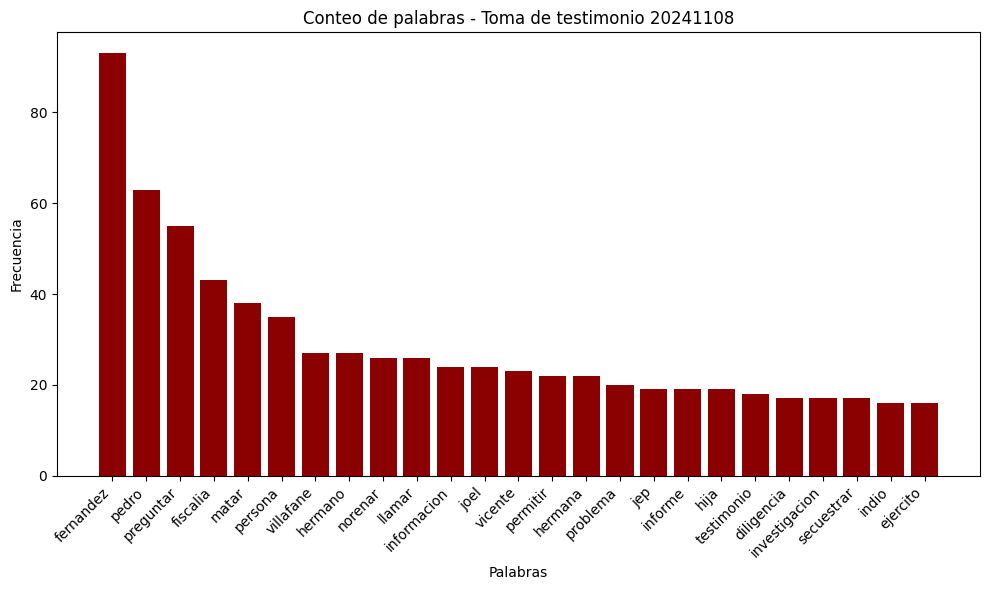

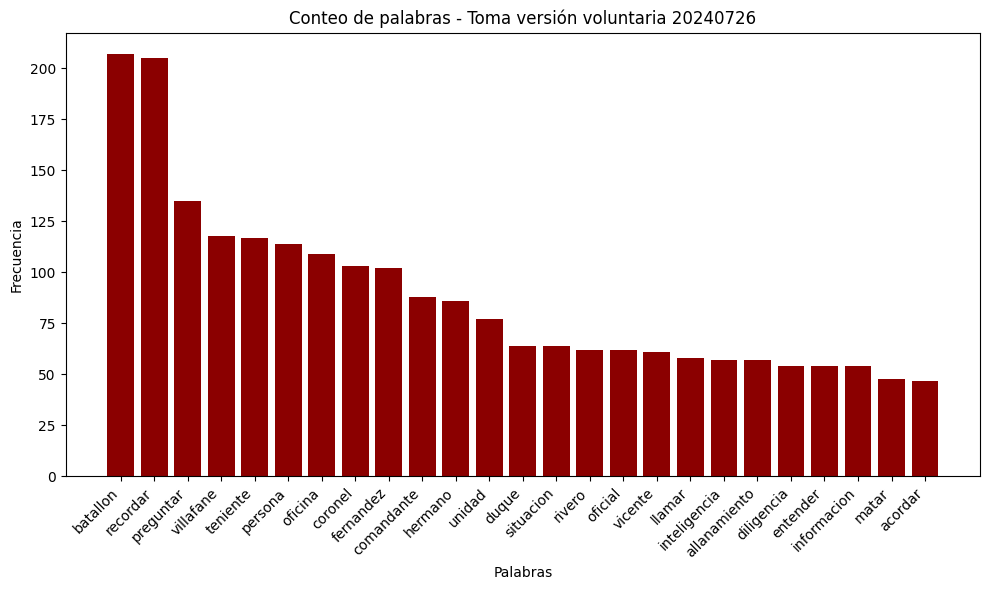

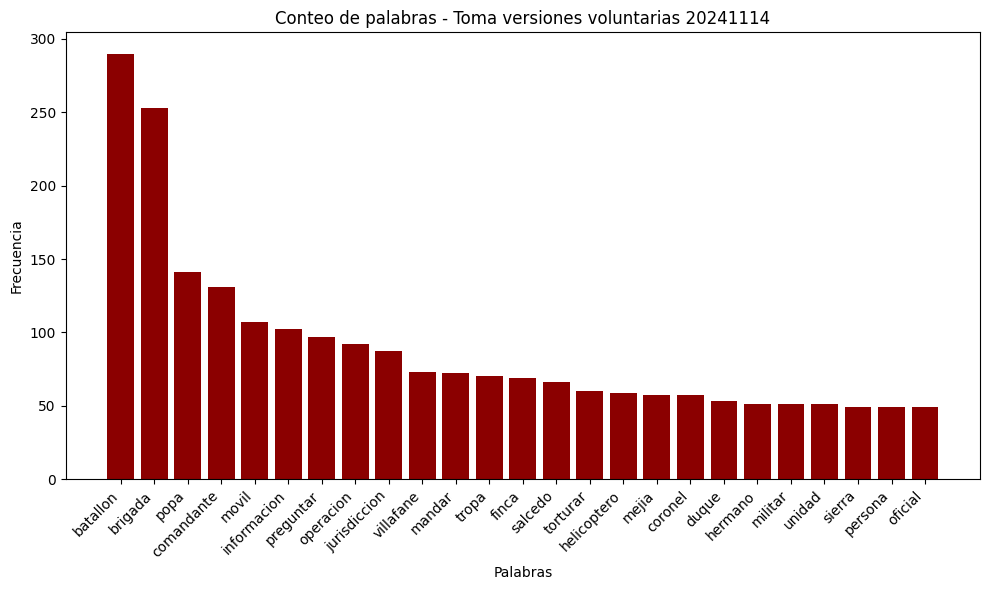

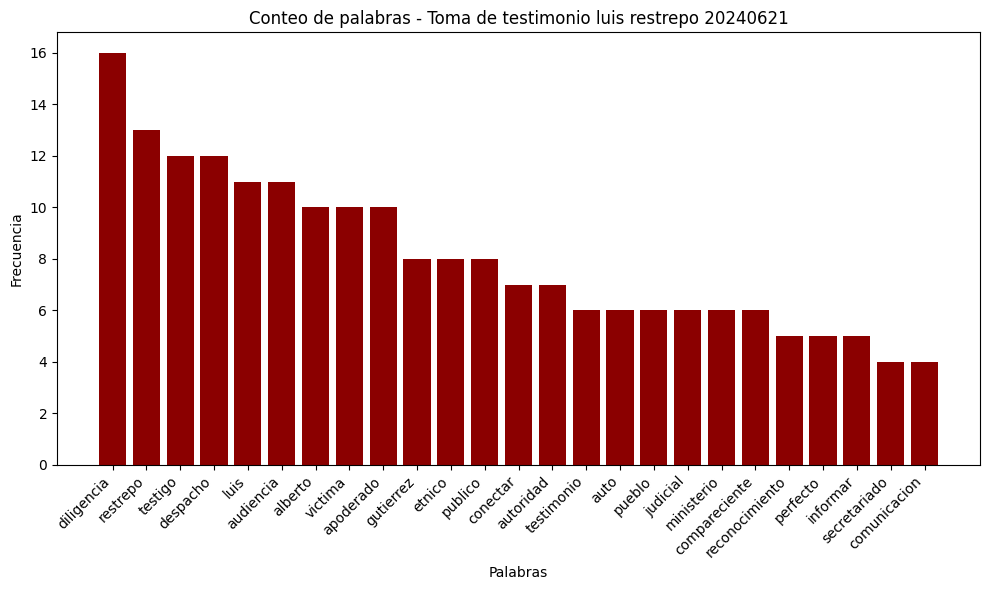

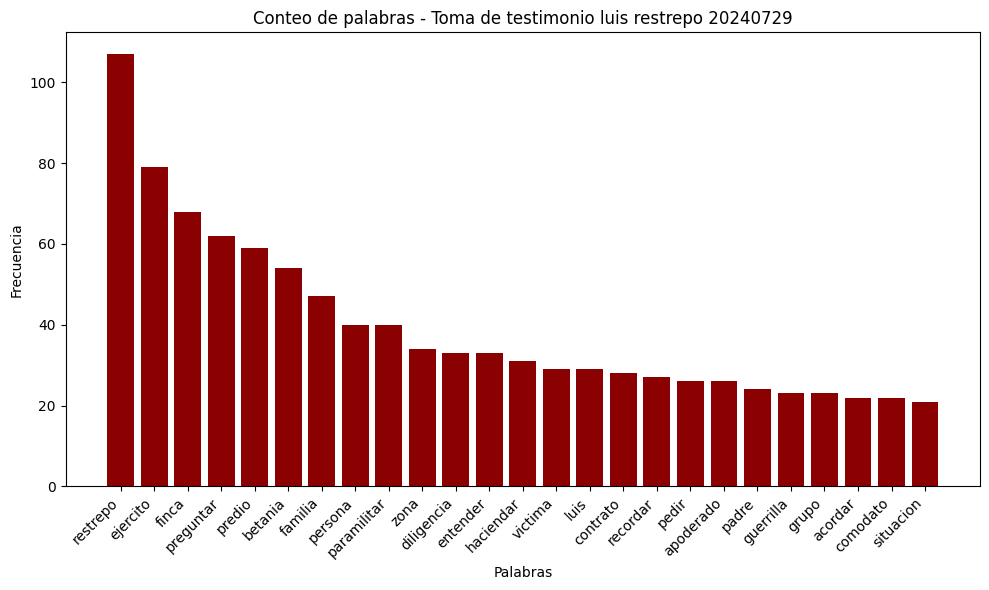

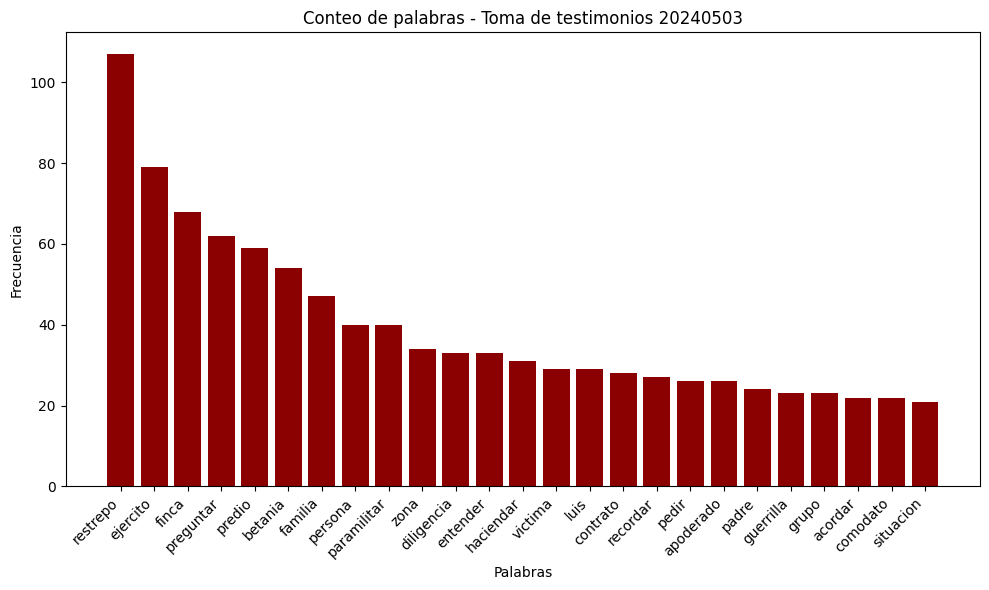

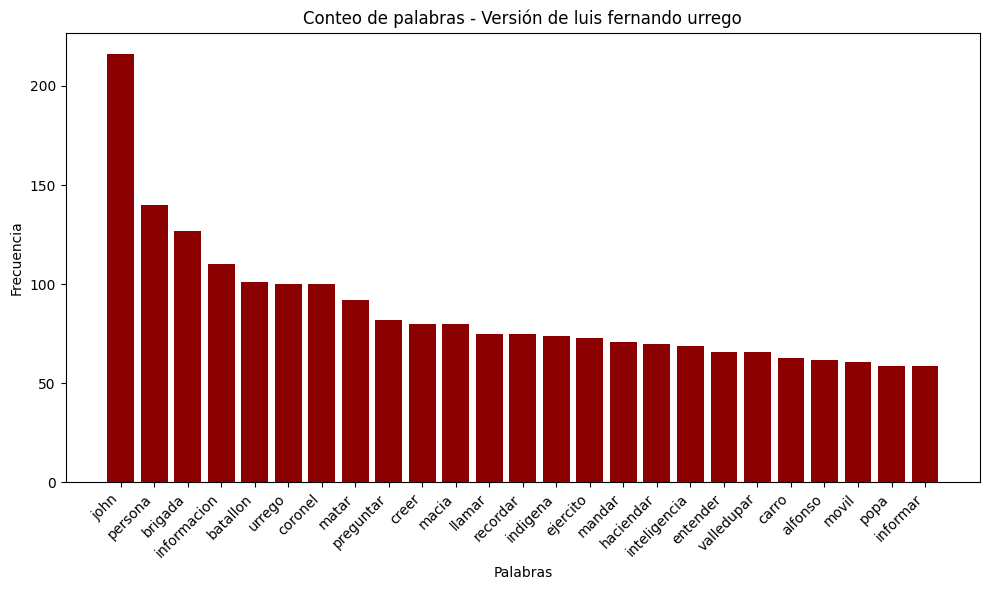

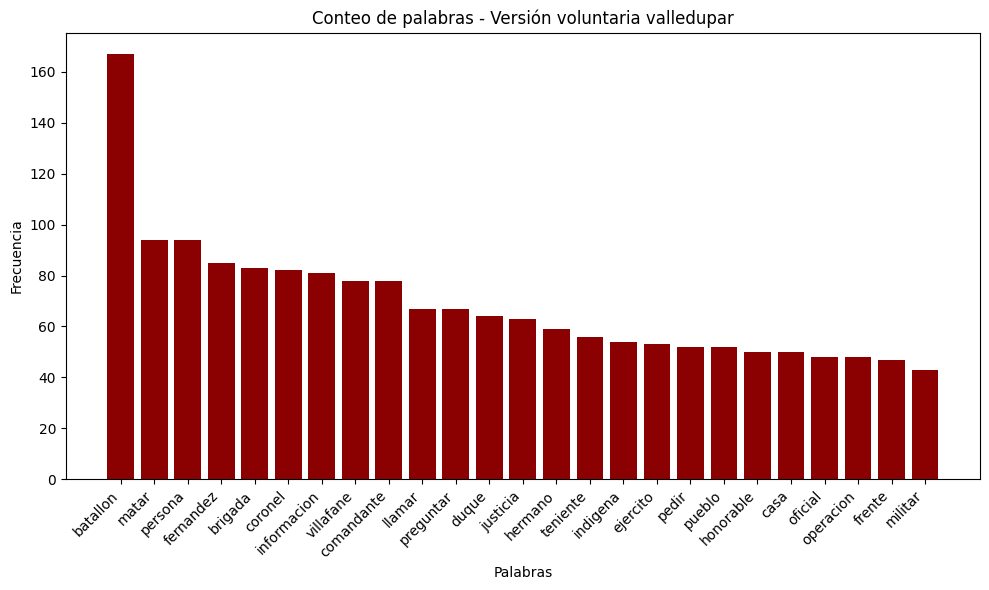

In [ ]:
#Distribución de frecuencias de términos
for nombre, datos in textos_skipgramas_filtrados.items():
    texto = datos["texto_sin_stopwords"]
    tokens = texto.split()
    frecuencia_palabras = FreqDist(tokens)
    palabras_repetidas = frecuencia_palabras.most_common(25)
    palabras, frecuencias = zip(*palabras_repetidas)

    plt.figure(figsize=(10, 6))
    plt.bar(palabras, frecuencias, color="darkred")
    plt.xlabel('Palabras')
    plt.ylabel('Frecuencia')
    plt.title(f"Conteo de palabras - {nombre.capitalize()}")
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()


In [ ]:
##Frecuencia de palabras por subanálisis:
tablas_frecuencias = {}

for nombre, datos in textos_skipgramas_filtrados.items():
    texto = datos["texto_sin_stopwords"]
    tokens = texto.split()
    frecuencia_palabras = FreqDist(tokens)
    palabras_repetidas = frecuencia_palabras.most_common(15)

    tabla_frecuencias = pd.DataFrame(palabras_repetidas, columns=['Palabra', 'Frecuencia'])
    tablas_frecuencias[nombre] = tabla_frecuencias

    print(f"\n Frecuencias para: {nombre}")
    print(tabla_frecuencias)

tabla_final = pd.concat(tablas_frecuencias, names=['Grupo']).reset_index(level=0)
tabla_final.reset_index(drop=True, inplace=True)


 Frecuencias para: Toma de testimonio 20241108
        Palabra  Frecuencia
0     fernandez          93
1         pedro          63
2     preguntar          55
3      fiscalia          43
4         matar          38
5       persona          35
6     villafane          27
7       hermano          27
8       norenar          26
9        llamar          26
10  informacion          24
11         joel          24
12      vicente          23
13     permitir          22
14      hermana          22

 Frecuencias para: Toma versión voluntaria 20240726
       Palabra  Frecuencia
0     batallon         207
1     recordar         205
2    preguntar         135
3    villafane         118
4     teniente         117
5      persona         114
6      oficina         109
7      coronel         103
8    fernandez         102
9   comandante          88
10     hermano          86
11      unidad          77
12       duque          64
13   situacion          64
14      rivero          62

 Frecuencias para:

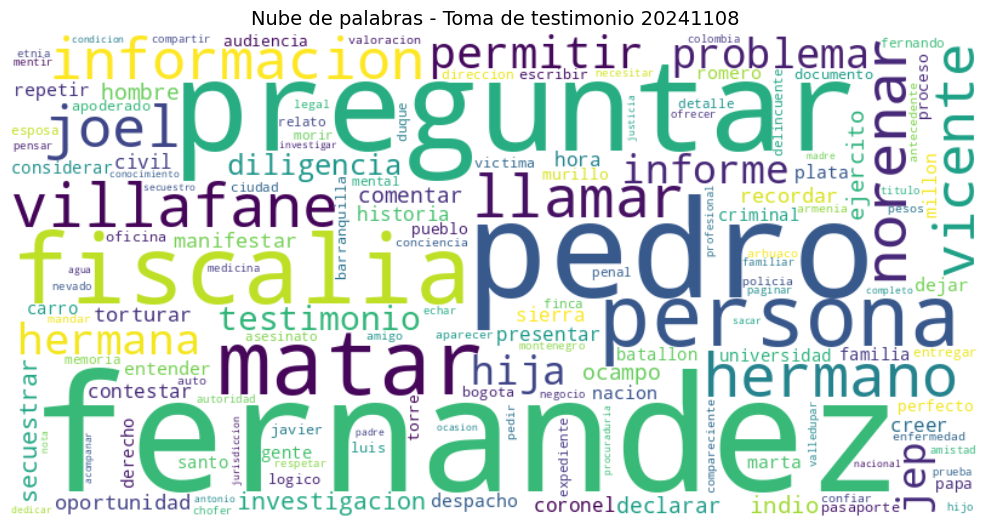

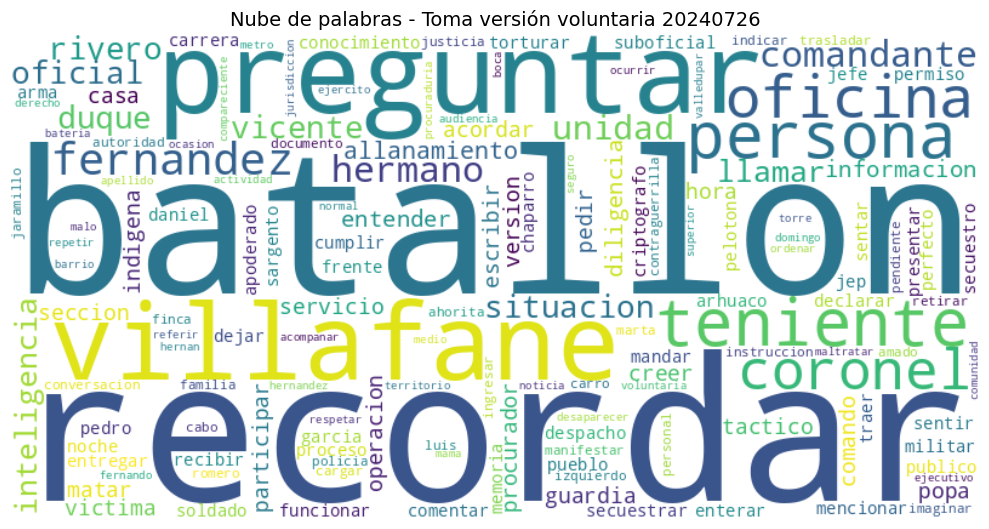

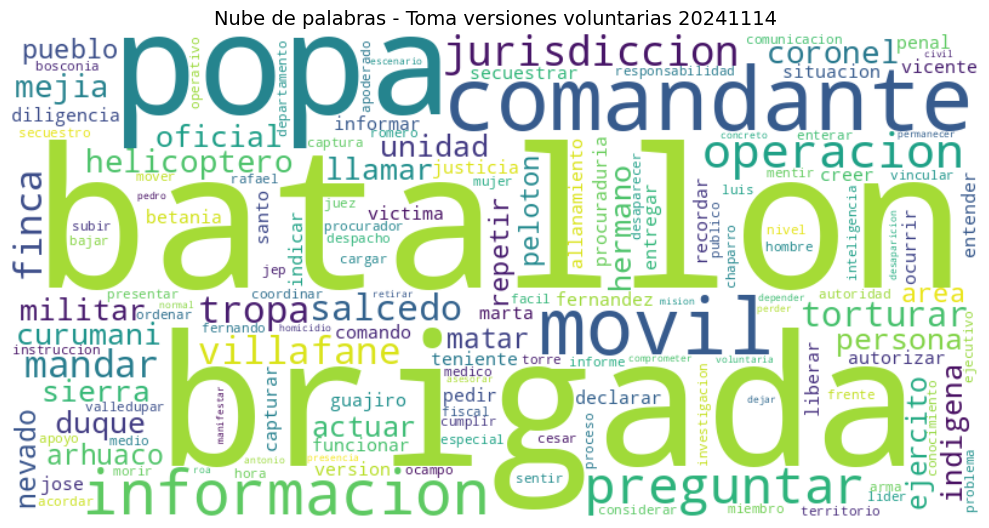

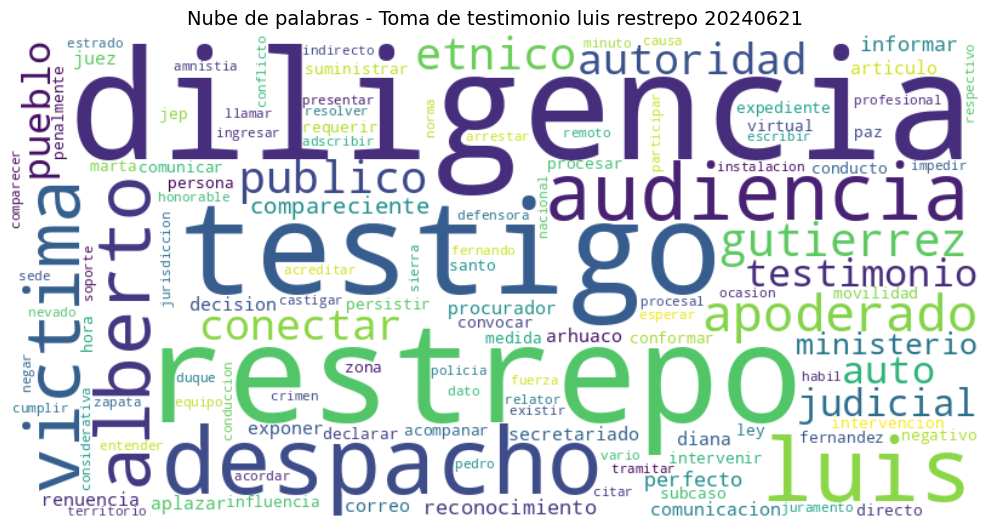

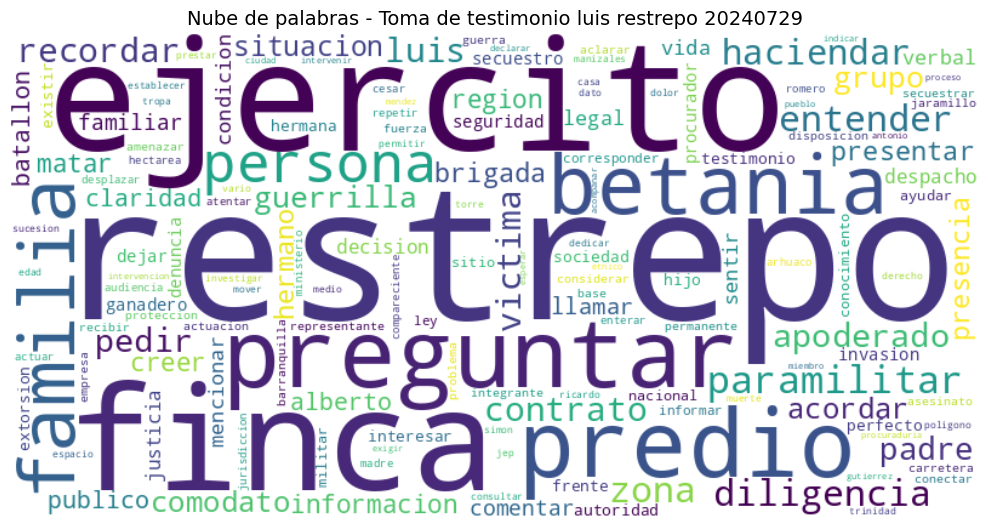

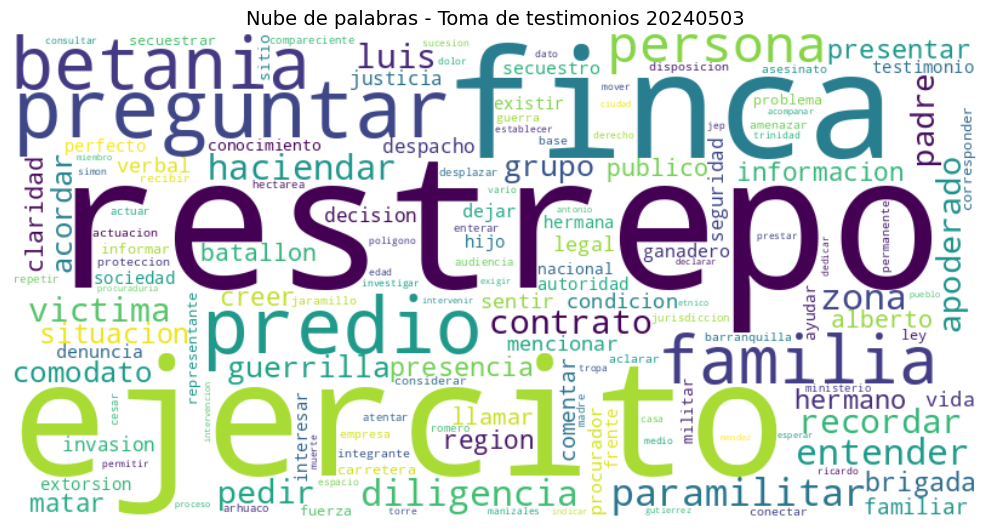

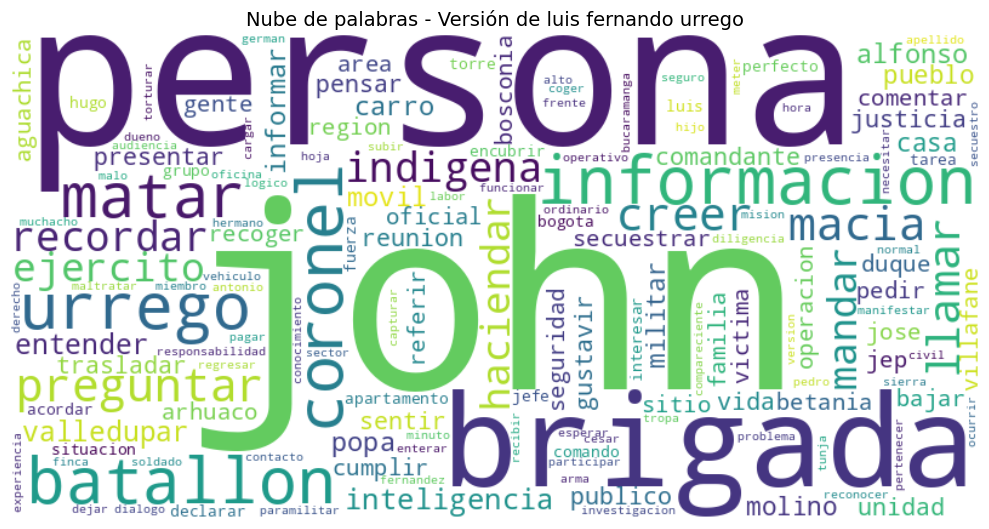

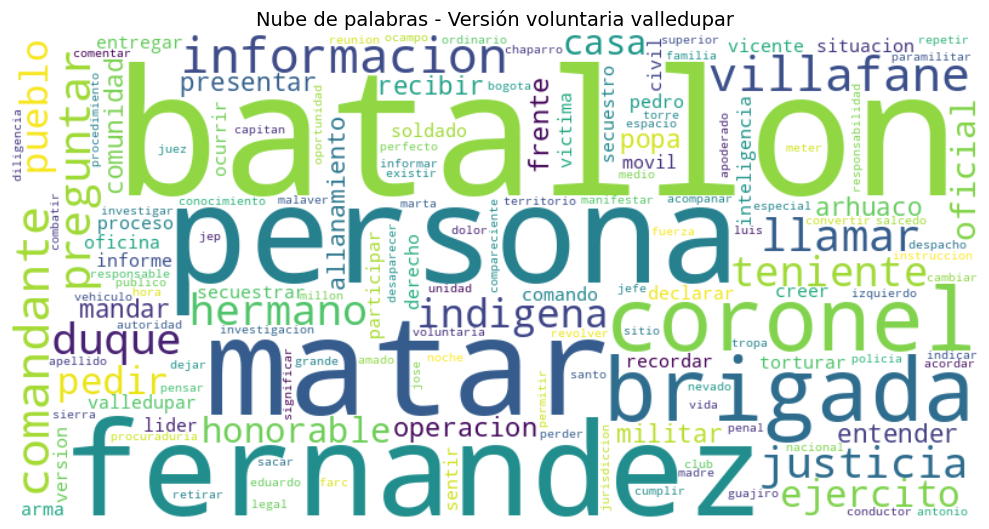

In [ ]:
#nube de palabras por subanálisis:
for nombre, datos in textos_skipgramas_filtrados.items():
    texto = datos["texto_sin_stopwords"]
    tokens = texto.split()
    frecuencia_palabras = FreqDist(tokens)

    nube = WordCloud(width=800, height=400,
        background_color='white',
        max_words=150
    ).generate_from_frequencies(frecuencia_palabras)

    plt.figure(figsize=(10, 6))
    plt.imshow(nube, interpolation='bilinear')
    plt.axis('off')
    plt.title(f"Nube de palabras - {nombre.capitalize()}", fontsize=14)
    plt.tight_layout()
    plt.show()

# **ANÁLISIS DE SENTIMIENTO**

In [ ]:
import warnings
warnings.filterwarnings('ignore', category=UserWarning, module='openpyxl')

ruta_excel = "C:/Users/Desktop/Casos_JEP/emociones.xlsx"
lexico = pd.read_excel(ruta_excel, engine="openpyxl")
lexico = lexico.rename(columns={'Spanish Translation': 'Palabra'})

lexico['Palabra'] = (
    lexico['Palabra'].astype(str).str.lower().str.strip().apply(unidecode).str.replace(r'[^a-zñáéíóúü\s]', '', regex=True)
    .str.replace(r'\s+', ' ', regex=True))

columnas_emociones = [
    'Positive','Negative','Anger','Anticipation','Disgust','Fear','Joy','Sadness','Surprise','Trust']

lexico[columnas_emociones] = lexico[columnas_emociones].fillna(0).astype(int)
lexico = lexico.groupby('Palabra', as_index=False)[columnas_emociones].max()
emociones = lexico.set_index('Palabra').to_dict(orient='index')


resultados = []
for nombre, datos in textos_skipgramas_filtrados.items():
    texto = datos["texto_sin_stopwords"]

    # Normalizar
    tokens = [ re.sub(r'\s+', ' ',re.sub(r'[^a-zñáéíóúü\s]', '',
                      unidecode(t.lower().strip())))
        for t in word_tokenize(texto)]

    conteo = Counter({emo: 0 for emo in columnas_emociones})

    for token in tokens:
        if token in emociones:
            for emo, valor in emociones[token].items():
                conteo[emo] += valor

    conteo['Texto'] = nombre
    resultados.append(conteo)

df_emociones = pd.DataFrame(resultados)
df_emociones = df_emociones[['Texto'] + columnas_emociones]

# Traducir nombres de columnas
df_emociones = df_emociones.rename(columns={'Positive': 'Positivo','Negative': 'Negativo','Anger': 'Ira',
    'Anticipation': 'Anticipación','Disgust': 'Disgusto','Fear': 'Miedo','Joy': 'Alegría','Sadness': 'Tristeza',
    'Surprise': 'Sorpresa', 'Trust': 'Confianza'})
print(df_emociones.head())

                                       Texto  Positivo  Negativo  Ira  \
0                Toma de testimonio 20241108       572       321  221   
1           Toma versión voluntaria 20240726      1854       707  532   
2        Toma versiones voluntarias 20241114      1597       958  576   
3  Toma de testimonio Luis Restrepo 20240621        93        46   20   
4  Toma de testimonio Luis Restrepo 20240729       613       480  255   

   Anticipación  Disgusto  Miedo  Alegría  Tristeza  Sorpresa  Confianza  
0           174        84    253      125       232       130        419  
1           435       175    733      307       488       239       1446  
2           432       135    877      238       373       222       1239  
3            51         5     25       21        20         5        108  
4           193       125    378       90       269       118        502  


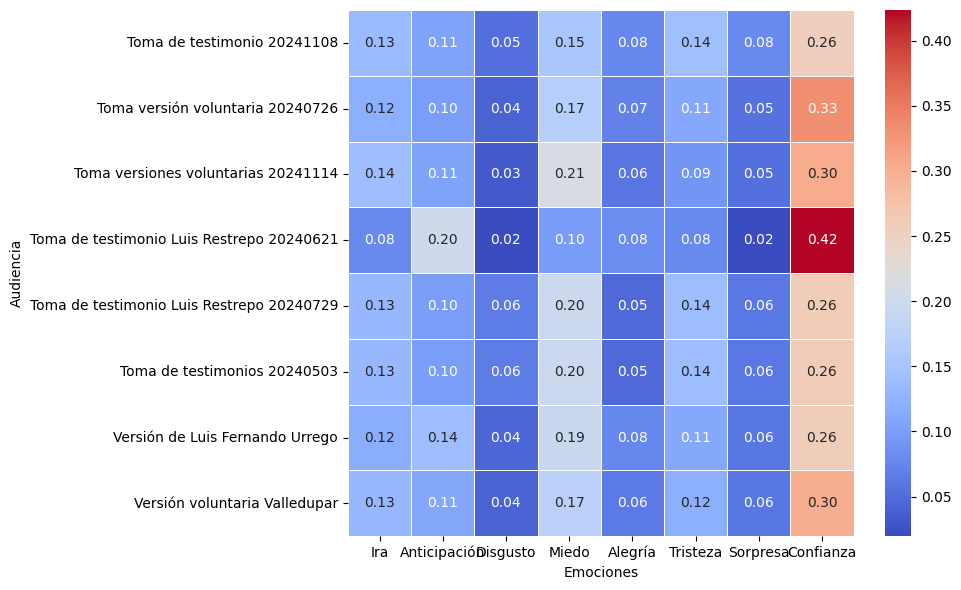

In [ ]:
#Mapa de calor de emociones
columnas_emociones = ["Ira" , "Anticipación" , "Disgusto" ,  "Miedo",  "Alegría" , "Tristeza" , "Sorpresa", "Confianza"]
df_heatmap = df_emociones[['Texto'] + columnas_emociones].copy()
df_heatmap.set_index('Texto', inplace=True)
df_heatmap_norm = df_heatmap.div(df_heatmap.sum(axis=1), axis=0)
plt.figure(figsize=(10, 6))
sns.heatmap(df_heatmap_norm, cmap='coolwarm', annot=True, fmt=".2f", linewidths=.5)
plt.xlabel('Emociones')
plt.ylabel('Audiencia')
plt.tight_layout()
plt.show()


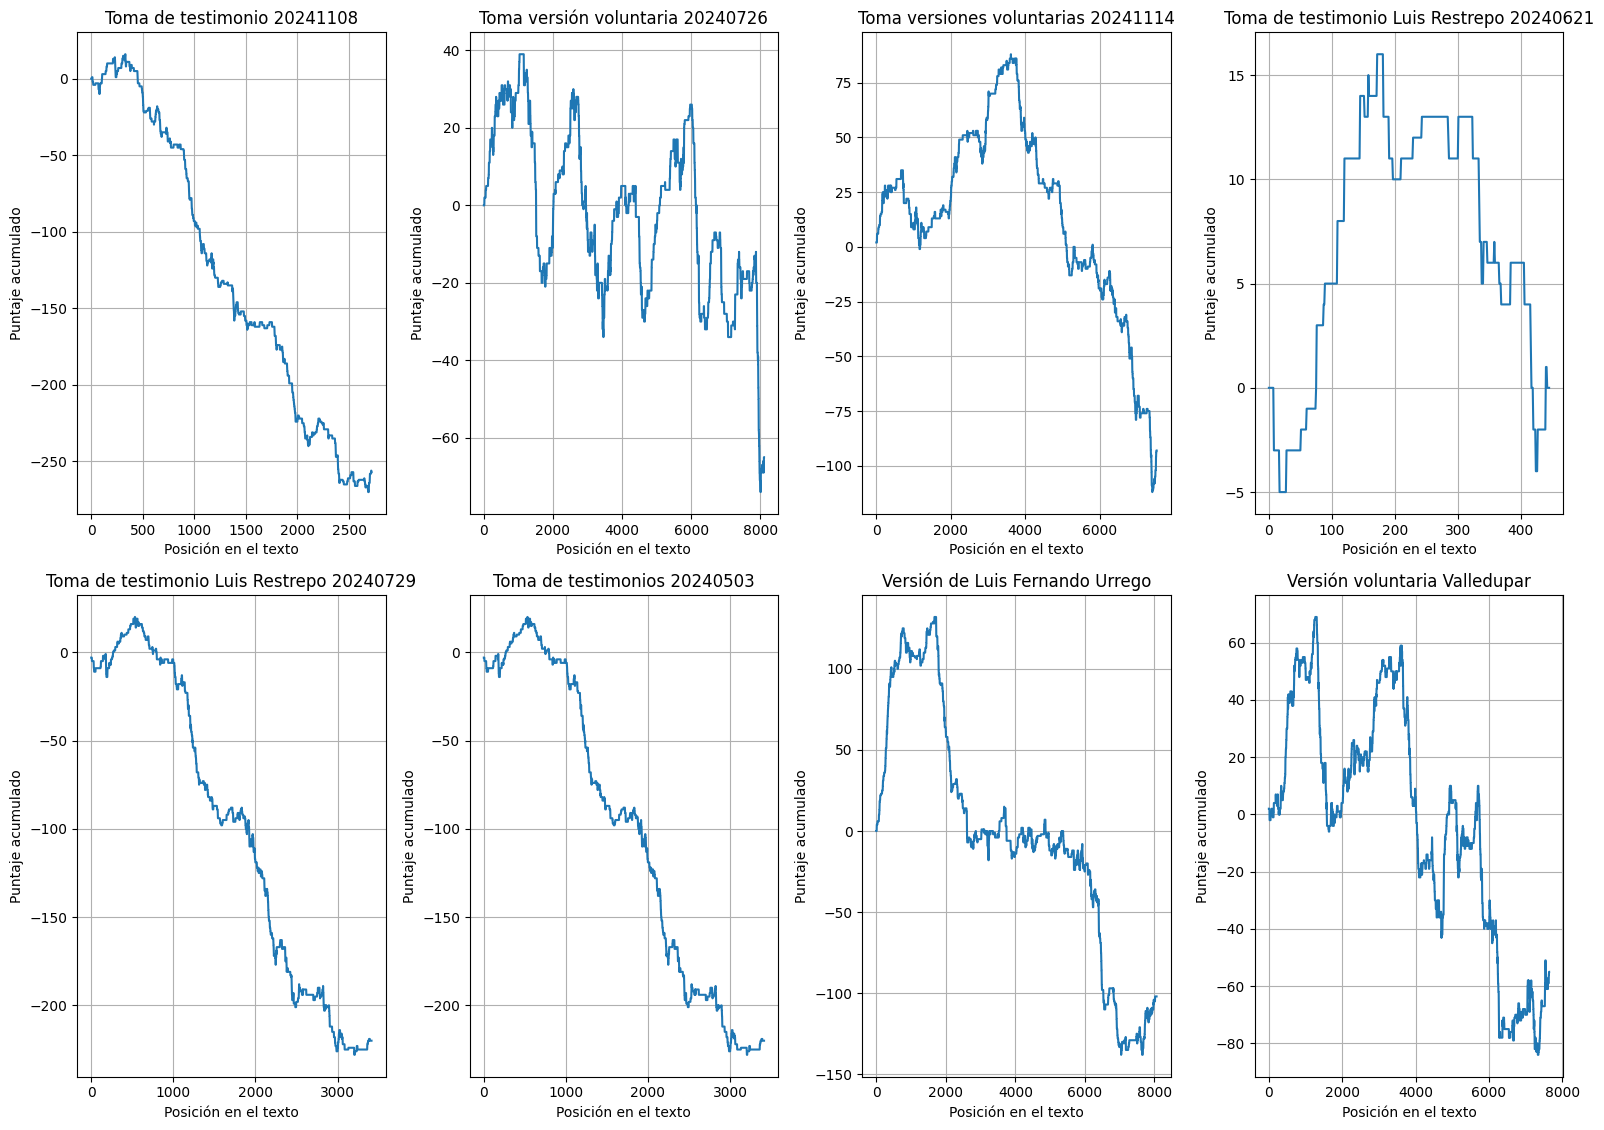

In [ ]:
##Grafico de sentimiento acumulado mediante diccionario AFINN
afinn = pd.read_csv("C:/Users/Desktop/Casos_JEP/material_adicional/lexico_afinn.csv")
afinn['palabra'] = afinn['palabra'].str.lower().str.strip()
afinn_dict = dict(zip(afinn['palabra'], afinn['puntuacion']))

tendencias_afinn = {}
for nombre, datos in textos_skipgramas_filtrados.items():
    texto = datos["texto_sin_stopwords"]
    tokens = [
        unidecode(t.lower().strip())
        for t in word_tokenize(texto)]
    puntajes = [
        afinn_dict.get(token, 0)
        for token in tokens]

    df = pd.DataFrame({"palabra": tokens, "puntaje": puntajes})
    df["sentimiento_acumulado"] = df["puntaje"].cumsum()
    tendencias_afinn[nombre] = df

n = len(tendencias_afinn)
ncols = 4
nrows = math.ceil(n / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(16, 6* nrows))
axes = axes.flatten()

for ax, (nombre, df) in zip(axes, tendencias_afinn.items()):
    ax.plot(df.index, df["sentimiento_acumulado"])
    ax.set_title(f"{nombre}")
    ax.set_xlabel("Posición en el texto")
    ax.set_ylabel("Puntaje acumulado")
    ax.grid(True)

for i in range(len(tendencias_afinn), len(axes)):
    axes[i].axis("off")
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()